# Feature Importance Analysis

Train a GBM model on the dry-only dataset, extract feature importances, and evaluate whether the new circuit characteristics (`track_length_km`, `n_corners`, `tire_stress`, `pit_loss_seconds`) are pulling their weight.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid", palette="colorblind")
pd.set_option("display.max_columns", None)

## 1. Train GBM on dry-only data

In [2]:
from f1deg.config import load_config
from f1deg.models.gbm import GBMDegradationModel

config = load_config(model_name="gbm")
df = pd.read_parquet("../data/processed/laps_clean.parquet")
print(f"Training data: {len(df)} laps, {df['race_id'].nunique()} races")
print(f"Compounds: {df['compound'].value_counts().to_dict()}")

model = GBMDegradationModel()
model.fit(df, config)
print("Model trained.")

Training data: 78217 laps, 90 races
Compounds: {'HARD': 37852, 'MEDIUM': 30453, 'SOFT': 9912}


Model trained.


## 2. Feature importance (gain-based)

In [3]:
# Build feature name list matching the model's X columns
feature_names = model.feature_cols + model.categorical_cols
importances = model.model_median.feature_importances_

imp_df = pd.DataFrame(
    {
        "feature": feature_names,
        "importance": importances,
    }
).sort_values("importance", ascending=False)
imp_df["pct"] = imp_df["importance"] / imp_df["importance"].sum() * 100
imp_df["cumulative_pct"] = imp_df["pct"].cumsum()

display(imp_df.reset_index(drop=True))

,feature,importance,pct,cumulative_pct
0,circuit_baseline_pace,0.272168,27.216764,27.216764
1,track_length_km,0.164538,16.453794,43.670559
2,n_corners,0.090785,9.078514,52.749073
3,circuit_id,0.026771,2.677123,55.426197
4,fuel_mass_kg,0.022054,2.205441,57.631638
5,position,0.021617,2.161727,59.793365
6,fp_deg_rate_medium,0.021515,2.151520,61.944885
7,race_progress,0.019820,1.981959,63.926846
8,lap_time_delta,0.019748,1.974831,65.901680
9,fp_deg_rate_soft,0.019683,1.968268,67.869949


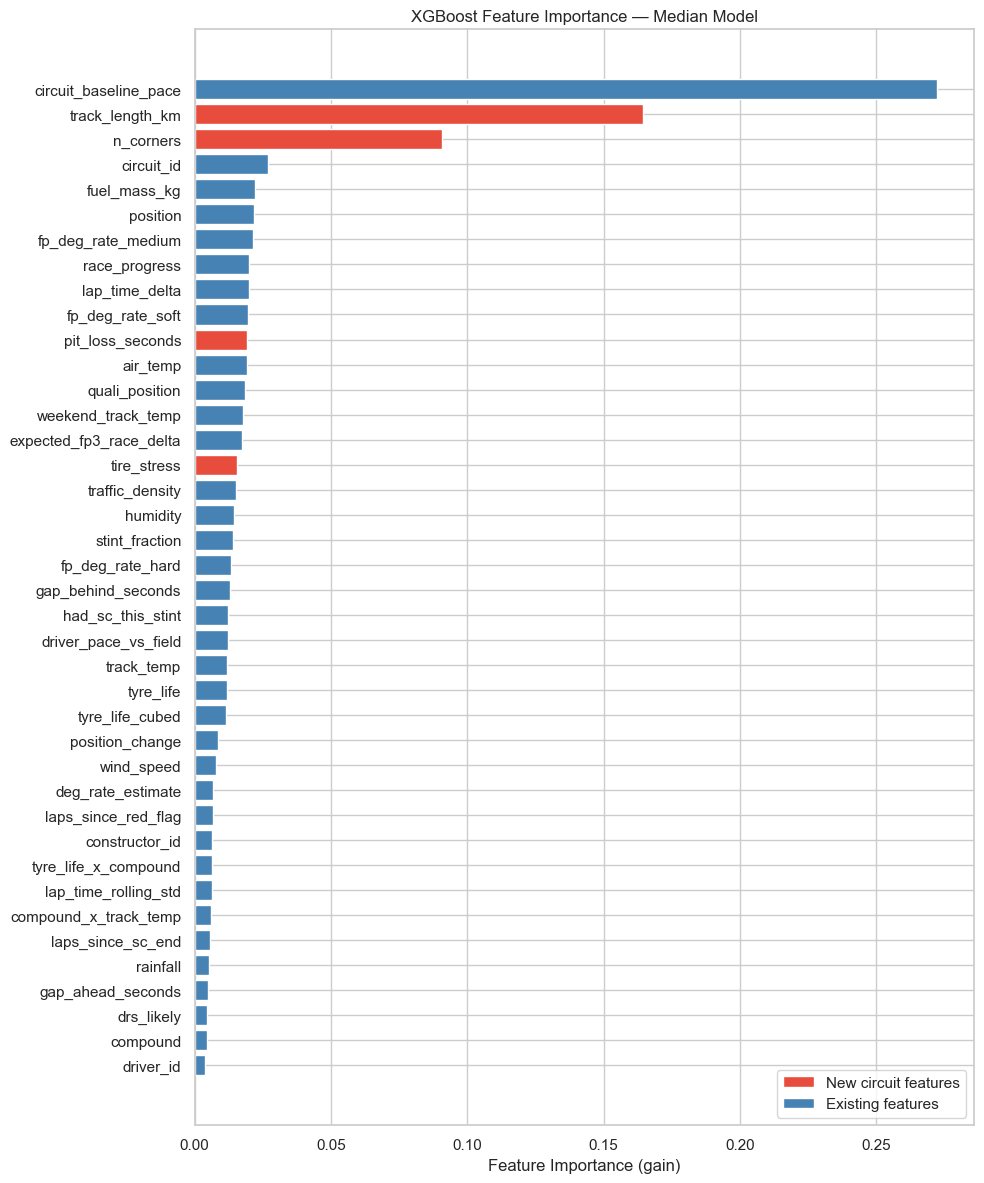

In [4]:
from matplotlib.patches import Patch

fig, ax = plt.subplots(figsize=(10, max(6, len(imp_df) * 0.3)))

# Color new circuit features differently
circuit_features = {"track_length_km", "n_corners", "tire_stress", "pit_loss_seconds"}
colors = ["#e74c3c" if f in circuit_features else "steelblue" for f in imp_df["feature"]]

ax.barh(range(len(imp_df)), imp_df["importance"].values, color=colors)
ax.set_yticks(range(len(imp_df)))
ax.set_yticklabels(imp_df["feature"].values)
ax.invert_yaxis()
ax.set_xlabel("Feature Importance (gain)")
ax.set_title("XGBoost Feature Importance — Median Model")

# Add legend

legend_elements = [
    Patch(facecolor="#e74c3c", label="New circuit features"),
    Patch(facecolor="steelblue", label="Existing features"),
]
ax.legend(handles=legend_elements, loc="lower right")

plt.tight_layout()
plt.show()

### Circuit features contribution

In [5]:
circuit_imp = imp_df[imp_df["feature"].isin(circuit_features)]
total_circuit_pct = circuit_imp["pct"].sum()

print(f"Circuit features total importance: {total_circuit_pct:.1f}%")
print()
for _, row in circuit_imp.iterrows():
    rank = imp_df["feature"].tolist().index(row["feature"]) + 1
    print(f"  {row['feature']:.<25} {row['pct']:.1f}%  (rank {rank}/{len(imp_df)})")

# Compare with circuit_id categorical
cid_row = imp_df[imp_df["feature"] == "circuit_id"]
if not cid_row.empty:
    print(f"\n  circuit_id (categorical): {cid_row['pct'].values[0]:.1f}%")
    print(f"  Numeric circuit features add {total_circuit_pct:.1f}% on top of circuit_id")

Circuit features total importance: 29.0%

  track_length_km.......... 16.5%  (rank 2/40)
  n_corners................ 9.1%  (rank 3/40)
  pit_loss_seconds......... 1.9%  (rank 11/40)
  tire_stress.............. 1.6%  (rank 16/40)

  circuit_id (categorical): 2.7%
  Numeric circuit features add 29.0% on top of circuit_id


## 3. Feature importance by type (XGBoost native)

Compare gain, weight (split count), and cover importance types.

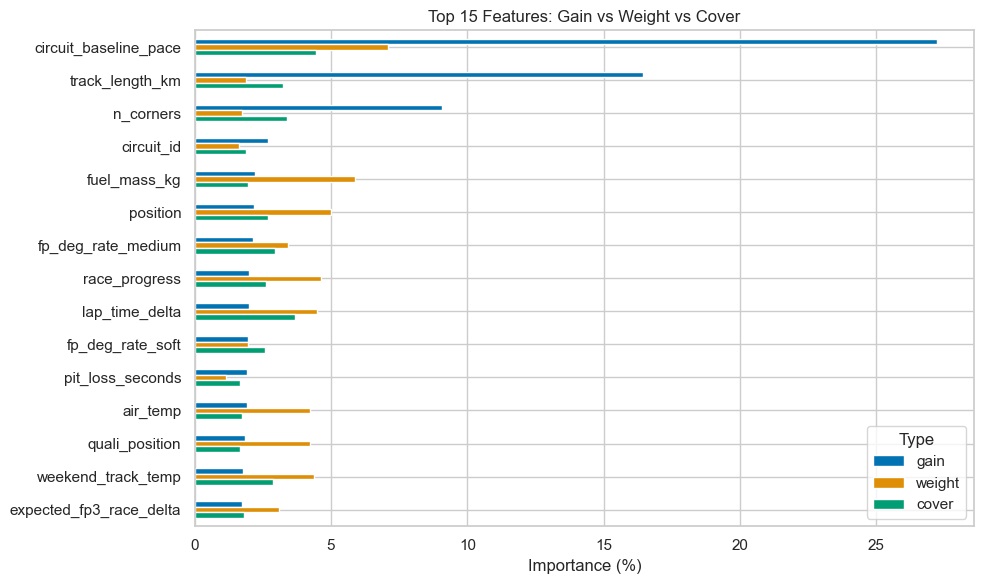

In [6]:
booster = model.model_median.get_booster()

imp_types = {}
for imp_type in ["gain", "weight", "cover"]:
    raw = booster.get_score(importance_type=imp_type)
    # Map f0, f1, ... back to feature names
    mapped = {}
    for k, v in raw.items():
        idx = int(k.replace("f", ""))
        if idx < len(feature_names):
            mapped[feature_names[idx]] = v
    imp_types[imp_type] = mapped

imp_compare = pd.DataFrame(imp_types).fillna(0)
# Normalize each column to percentages
for col in imp_compare.columns:
    imp_compare[col] = imp_compare[col] / imp_compare[col].sum() * 100

# Show top 15 by gain
top_features = imp_compare.sort_values("gain", ascending=False).head(15)

fig, ax = plt.subplots(figsize=(10, 6))
top_features.plot.barh(ax=ax)
ax.invert_yaxis()
ax.set_xlabel("Importance (%)")
ax.set_title("Top 15 Features: Gain vs Weight vs Cover")
ax.legend(title="Type")
plt.tight_layout()
plt.show()

## 4. Permutation importance (model-agnostic)

Shuffle each feature and measure the increase in MAE on a held-out set. More robust than gain-based importance for correlated features.

In [7]:
from sklearn.model_selection import GroupShuffleSplit

# Split data for permutation importance
X, y = model._prepare_xy(df, fit_encoders=False)
splitter = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=123)
_, test_idx = next(splitter.split(X, y, groups=df["race_id"].values))
X_test, y_test = X[test_idx], y[test_idx]

baseline_preds = model.model_median.predict(X_test)
baseline_mae = np.mean(np.abs(y_test - baseline_preds))
print(f"Baseline MAE on test split: {baseline_mae:.3f}s")

# Permutation importance
n_repeats = 5
rng = np.random.default_rng(42)
perm_results = []

for i, feat_name in enumerate(feature_names):
    mae_increases = []
    for _ in range(n_repeats):
        X_perm = X_test.copy()
        X_perm[:, i] = rng.permutation(X_perm[:, i])
        perm_preds = model.model_median.predict(X_perm)
        perm_mae = np.mean(np.abs(y_test - perm_preds))
        mae_increases.append(perm_mae - baseline_mae)
    perm_results.append(
        {
            "feature": feat_name,
            "mae_increase_mean": np.mean(mae_increases),
            "mae_increase_std": np.std(mae_increases),
        }
    )

perm_df = pd.DataFrame(perm_results).sort_values("mae_increase_mean", ascending=False)
perm_df = perm_df.reset_index(drop=True)
print("\nDone. Top features by permutation importance:")
display(perm_df.head(15))

Baseline MAE on test split: 0.464s



Done. Top features by permutation importance:


,feature,mae_increase_mean,mae_increase_std
0,circuit_baseline_pace,7.486941,0.046865
1,n_corners,1.476551,0.008898
2,track_length_km,0.989068,0.006030
3,fp_deg_rate_soft,0.352941,0.004239
4,expected_fp3_race_delta,0.323429,0.005624
5,fuel_mass_kg,0.261720,0.002261
6,circuit_id,0.240266,0.001576
7,fp_deg_rate_medium,0.239174,0.001344
8,position,0.173286,0.002175
9,race_progress,0.165850,0.002926


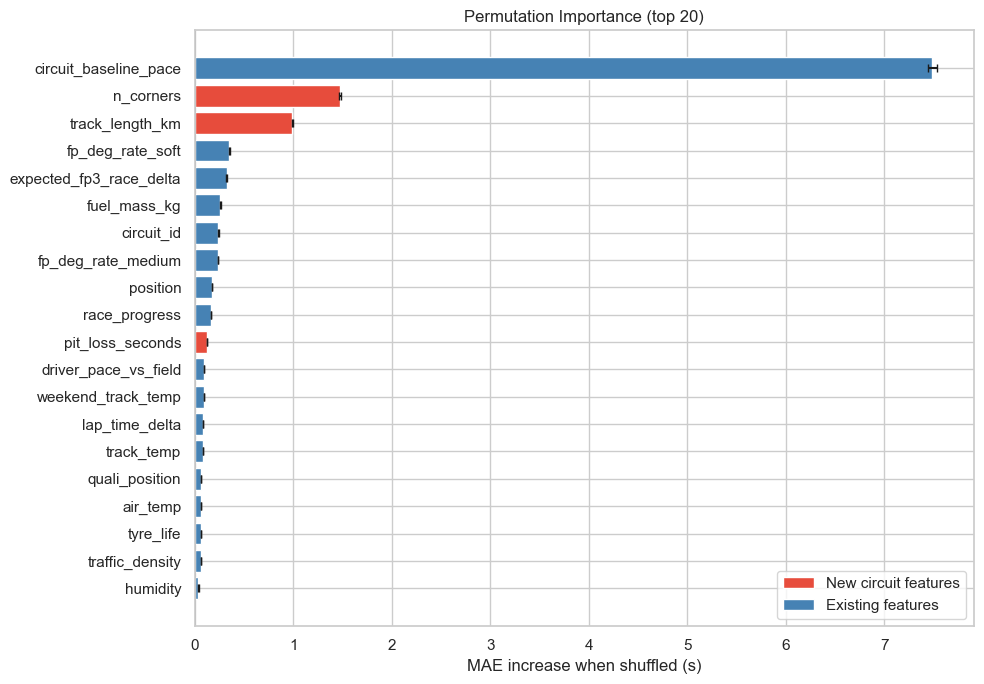

In [8]:
# Plot permutation importance
top_perm = perm_df.head(20)

fig, ax = plt.subplots(figsize=(10, 7))
colors_perm = ["#e74c3c" if f in circuit_features else "steelblue" for f in top_perm["feature"]]
ax.barh(
    range(len(top_perm)),
    top_perm["mae_increase_mean"].values,
    xerr=top_perm["mae_increase_std"].values,
    color=colors_perm,
    capsize=3,
)
ax.set_yticks(range(len(top_perm)))
ax.set_yticklabels(top_perm["feature"].values)
ax.invert_yaxis()
ax.set_xlabel("MAE increase when shuffled (s)")
ax.set_title("Permutation Importance (top 20)")
ax.axvline(0, color="gray", ls="-", lw=0.5)
ax.legend(handles=legend_elements, loc="lower right")
plt.tight_layout()
plt.show()

### Circuit features: permutation importance

In [9]:
circuit_perm = perm_df[perm_df["feature"].isin(circuit_features)]
print("Circuit feature permutation importance:")
for _, row in circuit_perm.iterrows():
    rank = perm_df["feature"].tolist().index(row["feature"]) + 1
    sign = "+" if row["mae_increase_mean"] > 0 else ""
    print(
        f"  {row['feature']:.<25} {sign}{row['mae_increase_mean']:.4f}s  (rank {rank}/{len(perm_df)})"
    )

print("\nInterpretation:")
print("  > 0 means shuffling hurts predictions (feature is useful)")
print("  ~ 0 means feature provides no predictive value")
print("  < 0 means shuffling helps (feature may be adding noise)")

Circuit feature permutation importance:
  n_corners................ +1.4766s  (rank 2/40)
  track_length_km.......... +0.9891s  (rank 3/40)
  pit_loss_seconds......... +0.1288s  (rank 11/40)
  tire_stress.............. +0.0133s  (rank 25/40)

Interpretation:
  > 0 means shuffling hurts predictions (feature is useful)
  ~ 0 means feature provides no predictive value
  < 0 means shuffling helps (feature may be adding noise)


## 5. SHAP values (if available)

SHAP provides per-prediction feature attributions — shows how each feature pushes predictions up or down.

In [10]:
try:
    import shap

    # Use a sample for speed
    sample_idx = rng.choice(len(X_test), size=min(2000, len(X_test)), replace=False)
    X_sample = X_test[sample_idx]

    explainer = shap.TreeExplainer(model.model_median)
    shap_values = explainer.shap_values(X_sample)

    fig, ax = plt.subplots(figsize=(10, 8))
    shap.summary_plot(
        shap_values,
        X_sample,
        feature_names=feature_names,
        show=False,
        max_display=20,
    )
    plt.title("SHAP Feature Importance")
    plt.tight_layout()
    plt.show()

    # SHAP for circuit features specifically
    circuit_idx = [feature_names.index(f) for f in circuit_features if f in feature_names]
    circuit_shap = np.abs(shap_values[:, circuit_idx]).mean(axis=0)
    print("\nMean |SHAP| for circuit features:")
    for f, s in zip([feature_names[i] for i in circuit_idx], circuit_shap, strict=False):
        print(f"  {f:.<25} {s:.4f}s")

except ImportError:
    print("shap not installed — skipping SHAP analysis.")
    print("Install with: uv add shap")

shap not installed — skipping SHAP analysis.
Install with: uv add shap


## 6. Partial dependence: circuit features

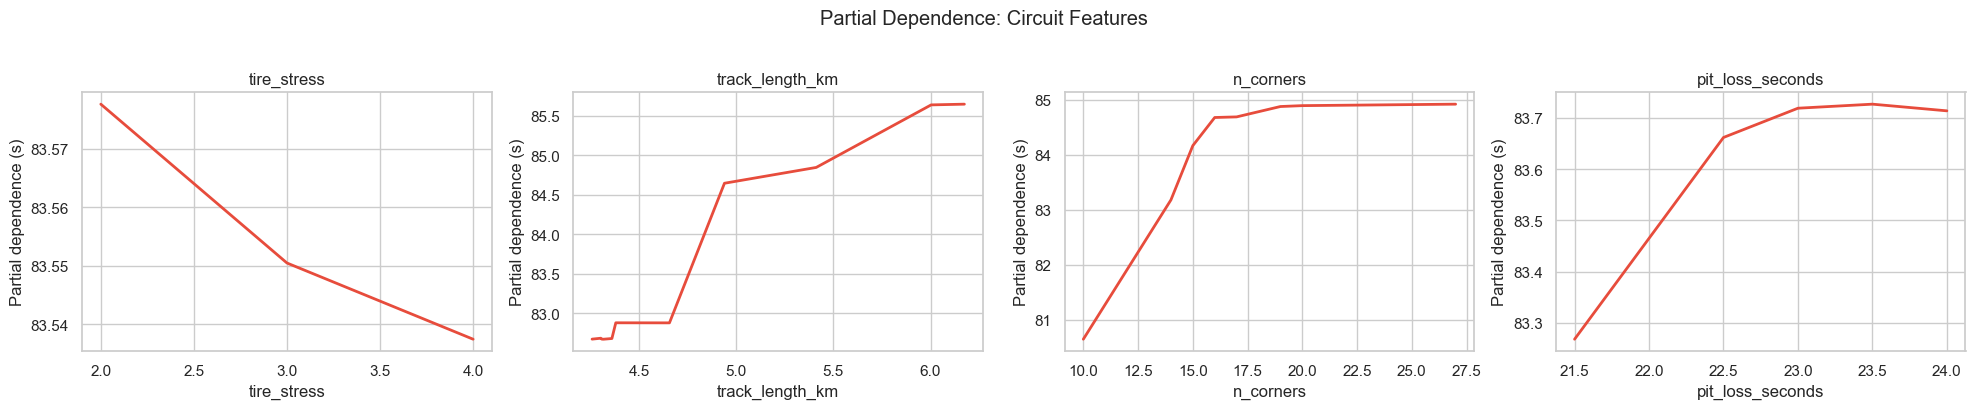

In [11]:
from sklearn.inspection import partial_dependence

circuit_feat_names = [f for f in circuit_features if f in feature_names]
circuit_feat_idx = [feature_names.index(f) for f in circuit_feat_names]

fig, axes = plt.subplots(1, len(circuit_feat_names), figsize=(5 * len(circuit_feat_names), 4))
if len(circuit_feat_names) == 1:
    axes = [axes]

# Use a subsample for speed
X_subsample = X_test[rng.choice(len(X_test), size=min(3000, len(X_test)), replace=False)]

for ax, feat_name, feat_idx in zip(axes, circuit_feat_names, circuit_feat_idx, strict=False):
    pdp = partial_dependence(
        model.model_median,
        X_subsample,
        features=[feat_idx],
        kind="average",
    )
    ax.plot(pdp["grid_values"][0], pdp["average"][0], lw=2, color="#e74c3c")
    ax.set_xlabel(feat_name)
    ax.set_ylabel("Partial dependence (s)")
    ax.set_title(feat_name)

plt.suptitle("Partial Dependence: Circuit Features", y=1.02)
plt.tight_layout()
plt.show()

## 7. Summary

In [12]:
print("=" * 60)
print("FEATURE IMPORTANCE SUMMARY")
print("=" * 60)
print(f"\nModel: XGBoost ({model.backend})")
print(f"Training laps: {len(df)}")
print(
    f"Features: {len(feature_names)} ({len(model.feature_cols)} numeric + {len(model.categorical_cols)} categorical)"
)
print(f"Baseline test MAE: {baseline_mae:.3f}s")

print("\n--- Top 10 by gain-based importance ---")
for _, row in imp_df.head(10).iterrows():
    marker = " *NEW*" if row["feature"] in circuit_features else ""
    print(f"  {row['feature']:.<30} {row['pct']:.1f}%{marker}")

print("\n--- Top 10 by permutation importance ---")
for _, (_, row) in enumerate(perm_df.head(10).iterrows()):
    marker = " *NEW*" if row["feature"] in circuit_features else ""
    print(f"  {row['feature']:.<30} +{row['mae_increase_mean']:.4f}s{marker}")

print("\n--- Circuit features assessment ---")
for feat in sorted(circuit_features):
    gain_row = imp_df[imp_df["feature"] == feat]
    perm_row = perm_df[perm_df["feature"] == feat]
    gain_pct = gain_row["pct"].values[0] if len(gain_row) > 0 else 0
    perm_val = perm_row["mae_increase_mean"].values[0] if len(perm_row) > 0 else 0
    verdict = "useful" if perm_val > 0.01 else "marginal" if perm_val > 0 else "not useful"
    print(f"  {feat:.<25} gain={gain_pct:.1f}%, perm_mae=+{perm_val:.4f}s -> {verdict}")

FEATURE IMPORTANCE SUMMARY

Model: XGBoost (xgboost)
Training laps: 78217
Features: 40 (36 numeric + 4 categorical)
Baseline test MAE: 0.464s

--- Top 10 by gain-based importance ---
  circuit_baseline_pace......... 27.2%
  track_length_km............... 16.5% *NEW*
  n_corners..................... 9.1% *NEW*
  circuit_id.................... 2.7%
  fuel_mass_kg.................. 2.2%
  position...................... 2.2%
  fp_deg_rate_medium............ 2.2%
  race_progress................. 2.0%
  lap_time_delta................ 2.0%
  fp_deg_rate_soft.............. 2.0%

--- Top 10 by permutation importance ---
  circuit_baseline_pace......... +7.4869s
  n_corners..................... +1.4766s *NEW*
  track_length_km............... +0.9891s *NEW*
  fp_deg_rate_soft.............. +0.3529s
  expected_fp3_race_delta....... +0.3234s
  fuel_mass_kg.................. +0.2617s
  circuit_id.................... +0.2403s
  fp_deg_rate_medium............ +0.2392s
  position...................... 